# Superstore Sales Data Analysis
Exploratory Data Analysis on Superstore Sales Dataset

In [167]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

In [168]:
df = pd.read_csv(r'E:\ML_learn\Superstore\Sample - Superstore.csv',encoding='latin1')

In [169]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [170]:
df.shape

(9994, 21)

In [171]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [173]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [ ]:
# Missing Values Check

In [174]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [175]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [176]:
df['year'] = df['Order Date'].dt.year

In [177]:
df['year'].head()

0    2016
1    2016
2    2016
3    2015
4    2015
Name: year, dtype: int64

In [178]:
# Graphs

In [191]:
# Sales by Category
# Technology category generates the highest sales compared to Furniture and Office Supplies.

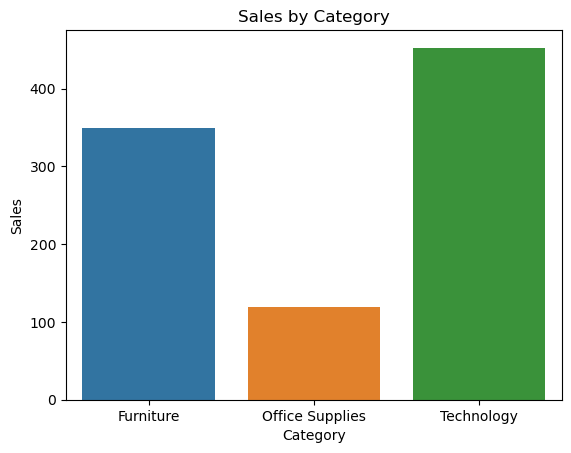

In [180]:
sns.barplot(x='Category', y='Sales', data=df, ci=None)
plt.title("Sales by Category")
plt.show()

In [192]:
# Profit by Category
# Technology category also contributes the highest profit, while Furniture shows comparatively lower profitability.

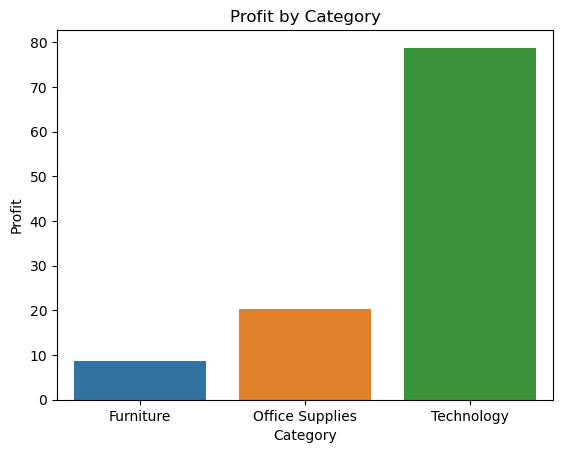

In [193]:
sns.barplot(x='Category', y='Profit', data=df,ci=None)
plt.title("Profit by Category")
plt.show()

In [194]:
# Sales by Region
# Sales distribution varies across regions, with some regions contributing significantly more to overall revenue.

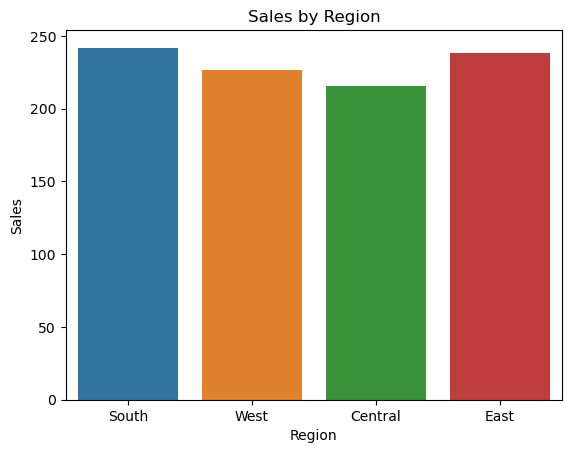

In [184]:
sns.barplot(x='Region', y='Sales', data=df,ci=None)
plt.title("Sales by Region")
plt.show()

In [195]:
# Sales Trend Over Time
# Sales show an increasing trend over the years, indicating business growth.

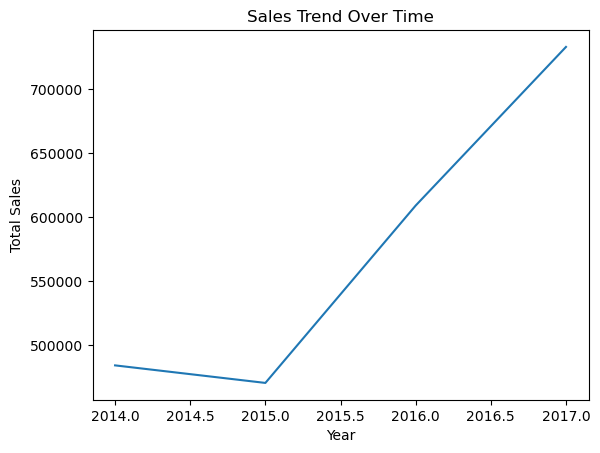

In [185]:
df.groupby('year')['Sales'].sum().plot(kind='line')

plt.title("Sales Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.show()

In [196]:
# Top 10 Products
# A small number of products contribute significantly to total sales, indicating key revenue-generating products.

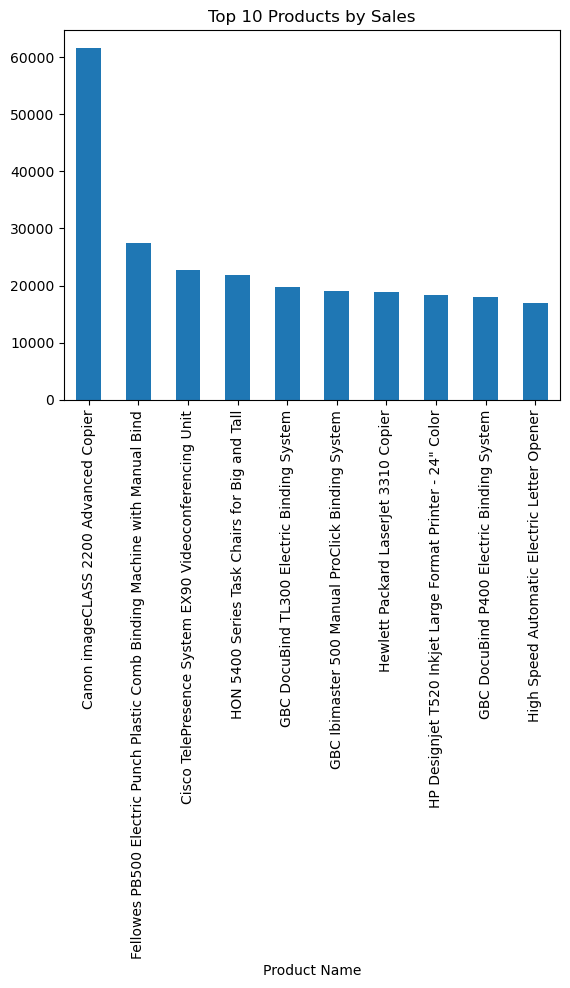

In [197]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='bar')
plt.title("Top 10 Products by Sales")
plt.show()

In [189]:
print("Key Insights:")

print("1. Technology category generates the highest sales.")
print("2. Certain regions contribute more to overall revenue.")
print("3. Sales have increased over the years.")
print("4. A small number of products contribute significantly to total sales.")

Key Insights:
1. Technology category generates the highest sales.
2. Certain regions contribute more to overall revenue.
3. Sales have increased over the years.
4. A small number of products contribute significantly to total sales.
